<a href="https://colab.research.google.com/github/marozta/Data-Science-Challenge3-Alura-ONE-G9/blob/main/Data_Science_Challenge3_Alura_ONE_G9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Importando las librerias necesarias para el trabajo
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Extrayendo el DataFrame en la variable df
df = pd.read_csv('/content/datos_telecomX_parte1.csv')

In [ ]:
datos = df.dropna()
datos

,id_cliente,churn,genero,adulto_mayor,pareja,dependientes,meses_contrato,servicio_internet,seguridad_en_linea,respaldo_en_linea,...,tv_streaming,peliculas_streaming,tipo_contrato,factura_electronica,metodo_pago,cargo_mensual,cargo_total,servicio_telefonico,multiples_lineas,cargo_diario
0,0002-ORFBO,0,Femenino,0,1,1,9,DSL,0,1,...,1,0,Anual,1,Cheque Postal,65.60,593.30,1,0,2.186667
1,0003-MKNFE,0,Masculino,0,0,0,9,DSL,0,0,...,0,1,Mensual,0,Cheque Postal,59.90,542.40,1,1,1.996667
2,0004-TLHLJ,1,Masculino,0,0,0,4,Fibra Óptica,0,0,...,0,0,Mensual,1,Cheque Electrónico,73.90,280.85,1,0,2.463333
3,0011-IGKFF,1,Masculino,1,1,0,13,Fibra Óptica,0,1,...,1,1,Mensual,1,Cheque Electrónico,98.00,1237.85,1,0,3.266667
4,0013-EXCHZ,1,Femenino,1,1,0,3,Fibra Óptica,0,0,...,1,0,Mensual,1,Cheque Postal,83.90,267.40,1,0,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,9987-LUTYD,0,Femenino,0,0,0,13,DSL,1,0,...,0,0,Anual,0,Cheque Postal,55.15,742.90,1,0,1.838333
7039,9992-RRAMN,1,Masculino,0,1,0,22,Fibra Óptica,0,0,...,0,1,Mensual,1,Cheque Electrónico,85.10,1873.70,1,1,2.836667
7040,9992-UJOEL,0,Masculino,0,0,0,2,DSL,0,1,...,0,0,Mensual,1,Cheque Postal,50.30,92.75,1,0,1.676667
7041,9993-LHIEB,0,Masculino,0,1,1,67,DSL,1,0,...,0,1,Doble Anual,0,Cheque Postal,67.85,4627.65,1,0,2.261667


In [ ]:
#Eliminar columnas irrelevantes: id_cliente, cargo_diario, meses_contrato
datos = datos.drop(columns=['id_cliente', 'cargo_diario', 'meses_contrato'], axis=1)
datos.head()

,churn,genero,adulto_mayor,pareja,dependientes,servicio_internet,seguridad_en_linea,respaldo_en_linea,proteccion_dispositivo,soporte_tecnico,tv_streaming,peliculas_streaming,tipo_contrato,factura_electronica,metodo_pago,cargo_mensual,cargo_total,servicio_telefonico,multiples_lineas
0,0,Femenino,0,1,1,DSL,0,1,0,1,1,0,Anual,1,Cheque Postal,65.6,593.30,1,0
1,0,Masculino,0,0,0,DSL,0,0,0,0,0,1,Mensual,0,Cheque Postal,59.9,542.40,1,1
2,1,Masculino,0,0,0,Fibra Óptica,0,0,1,0,0,0,Mensual,1,Cheque Electrónico,73.9,280.85,1,0
3,1,Masculino,1,1,0,Fibra Óptica,0,1,1,0,1,1,Mensual,1,Cheque Electrónico,98.0,1237.85,1,0
4,1,Femenino,1,1,0,Fibra Óptica,0,0,0,1,1,0,Mensual,1,Cheque Postal,83.9,267.40,1,0


In [ ]:
#Columnas categoricas
columnas_categoricas = datos.select_dtypes(include=['object']).columns

In [ ]:
#Aislando la Variable Churn
X = datos.drop('churn', axis=1)
y = datos['churn']

In [ ]:
#Importar Make_column_transformer y One Hot Encoder
#Definir y asignar una variable para las columnas de la variable X
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

columnas_datos = X.columns
columnas_datos

Index(['genero', 'adulto_mayor', 'pareja', 'dependientes', 'servicio_internet',
       'seguridad_en_linea', 'respaldo_en_linea', 'proteccion_dispositivo',
       'soporte_tecnico', 'tv_streaming', 'peliculas_streaming',
       'tipo_contrato', 'factura_electronica', 'metodo_pago', 'cargo_mensual',
       'cargo_total', 'servicio_telefonico', 'multiples_lineas'],
      dtype='object')

In [ ]:
#Convertir las variables en formatos numericos con onehotencodery makecolumntransfirer
one_hot = make_column_transformer(
    (OneHotEncoder(drop='first'), columnas_categoricas),
    remainder='passthrough', sparse_threshold=0
)

In [ ]:
#Usando fit transformamos y concatenamos los datos en
X = one_hot.fit_transform(X)

In [ ]:
#Unir tanto X como y en un nuevo DataFrame para analisis
#Se usa principalmente para visualizar los datos en graficos
X_df = pd.DataFrame(X, columns=one_hot.get_feature_names_out(columnas_datos))
datos_codificados = pd.concat([X_df, y], axis=1)

In [ ]:
X

array([[0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 6.56000e+01,
        5.93300e+02, 1.00000e+00],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 5.99000e+01,
        5.42400e+02, 1.00000e+00],
       [1.00000e+00, 1.00000e+00, 0.00000e+00, ..., 7.39000e+01,
        2.80850e+02, 1.00000e+00],
       ...,
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 5.03000e+01,
        9.27500e+01, 1.00000e+00],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 6.78500e+01,
        4.62765e+03, 1.00000e+00],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 5.90000e+01,
        3.70760e+03, 0.00000e+00]])

In [ ]:
#Ver como quedaron los nombres de las features
one_hot.get_feature_names_out(columnas_datos)

array(['onehotencoder__genero_Masculino',
       'onehotencoder__servicio_internet_Fibra Óptica',
       'onehotencoder__servicio_internet_No',
       'onehotencoder__seguridad_en_linea_1',
       'onehotencoder__seguridad_en_linea_No internet service',
       'onehotencoder__respaldo_en_linea_1',
       'onehotencoder__respaldo_en_linea_No internet service',
       'onehotencoder__proteccion_dispositivo_1',
       'onehotencoder__proteccion_dispositivo_No internet service',
       'onehotencoder__soporte_tecnico_1',
       'onehotencoder__soporte_tecnico_No internet service',
       'onehotencoder__tv_streaming_1',
       'onehotencoder__tv_streaming_No internet service',
       'onehotencoder__peliculas_streaming_1',
       'onehotencoder__peliculas_streaming_No internet service',
       'onehotencoder__tipo_contrato_Doble Anual',
       'onehotencoder__tipo_contrato_Mensual',
       'onehotencoder__metodo_pago_Cheque Postal',
       'onehotencoder__metodo_pago_Tarjeta de Crédito Aut

In [ ]:
#Visualización de los Datos en un DataFrame para un mejor analisis
pd.DataFrame(X, columns=one_hot.get_feature_names_out(columnas_datos))

,onehotencoder__genero_Masculino,onehotencoder__servicio_internet_Fibra Óptica,onehotencoder__servicio_internet_No,onehotencoder__seguridad_en_linea_1,onehotencoder__seguridad_en_linea_No internet service,onehotencoder__respaldo_en_linea_1,onehotencoder__respaldo_en_linea_No internet service,onehotencoder__proteccion_dispositivo_1,onehotencoder__proteccion_dispositivo_No internet service,onehotencoder__soporte_tecnico_1,...,onehotencoder__metodo_pago_Transferencia Bancaria Automática,onehotencoder__multiples_lineas_1,onehotencoder__multiples_lineas_No phone service,remainder__adulto_mayor,remainder__pareja,remainder__dependientes,remainder__factura_electronica,remainder__cargo_mensual,remainder__cargo_total,remainder__servicio_telefonico
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,1.0,1.0,65.60,593.30,1.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,59.90,542.40,1.0
2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,73.90,280.85,1.0
3,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,1.0,98.00,1237.85,1.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,1.0,83.90,267.40,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,55.15,742.90,1.0
7028,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,85.10,1873.70,1.0
7029,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,50.30,92.75,1.0
7030,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,67.85,4627.65,1.0


In [ ]:
#Convertir los datos para asegurar que sean utiles para modelos de
#Machine Learning
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
y

array([0, 0, 1, ..., 0, 0, 0])

In [ ]:
#Visualizar en porcentaje la Proporción de Cancelación
datos['churn'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%'

,proportion
churn,
0,73.42%
1,26.58%


In [ ]:
#Oversampling
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

In [ ]:
#Undersampling
from imblearn.under_sampling import RandomUnderSampler
under = RandomUnderSampler(random_state=42)
X_under, y_under = under.fit_resample(X, y)

In [ ]:
#Normalización de los datos
from sklearn.preprocessing import MinMaxScaler

normalizacion = MinMaxScaler()
X_train_normalizado = normalizacion.fit_transform(X)
pd.DataFrame(X_train_normalizado)

,0,1,2,3,4,5,6,7,8,9,...,19,20,21,22,23,24,25,26,27,28
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.471144,0.066294,1.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.414428,0.060420,1.0
2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.553731,0.030239,1.0
3,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.793532,0.140670,1.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.653234,0.028687,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.367164,0.083556,1.0
7028,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.665174,0.214043,1.0
7029,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.318905,0.008533,1.0
7030,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.493532,0.531831,1.0


In [ ]:
#Estandarización de los datos
from sklearn.preprocessing import StandardScaler

estandarizacion = StandardScaler()
X_train_estandarizado = estandarizacion.fit_transform(X)
pd.DataFrame(X_train_estandarizado)

,0,1,2,3,4,5,6,7,8,9,...,19,20,21,22,23,24,25,26,27,28
0,-1.009430,-0.886896,-0.52513,-0.633746,-0.52513,1.378330,-0.52513,-0.723918,-0.52513,1.564308,...,-0.529976,-0.854336,-0.327189,-0.440327,1.035617,1.533025,0.828939,0.026652,-0.745607,0.327189
1,0.990658,-0.886896,-0.52513,-0.633746,-0.52513,-0.725516,-0.52513,-0.723918,-0.52513,-0.639260,...,-0.529976,1.170500,-0.327189,-0.440327,-0.965608,-0.652305,-1.206361,-0.162819,-0.768063,0.327189
2,0.990658,1.127527,-0.52513,-0.633746,-0.52513,-0.725516,-0.52513,1.381372,-0.52513,-0.639260,...,-0.529976,-0.854336,-0.327189,-0.440327,-0.965608,-0.652305,0.828939,0.302548,-0.883456,0.327189
3,0.990658,1.127527,-0.52513,-0.633746,-0.52513,1.378330,-0.52513,1.381372,-0.52513,-0.639260,...,-0.529976,-0.854336,-0.327189,2.271039,1.035617,-0.652305,0.828939,1.103642,-0.461240,0.327189
4,-1.009430,1.127527,-0.52513,-0.633746,-0.52513,-0.725516,-0.52513,-0.723918,-0.52513,1.564308,...,-0.529976,-0.854336,-0.327189,2.271039,1.035617,-0.652305,0.828939,0.634952,-0.889390,0.327189
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,-1.009430,-0.886896,-0.52513,1.577918,-0.52513,-0.725516,-0.52513,-0.723918,-0.52513,1.564308,...,-0.529976,-0.854336,-0.327189,-0.440327,-0.965608,-0.652305,-1.206361,-0.320711,-0.679605,0.327189
7028,0.990658,1.127527,-0.52513,-0.633746,-0.52513,-0.725516,-0.52513,-0.723918,-0.52513,-0.639260,...,-0.529976,1.170500,-0.327189,-0.440327,1.035617,-0.652305,0.828939,0.674841,-0.180711,0.327189
7029,0.990658,-0.886896,-0.52513,-0.633746,-0.52513,1.378330,-0.52513,-0.723918,-0.52513,-0.639260,...,-0.529976,-0.854336,-0.327189,-0.440327,-0.965608,-0.652305,0.828939,-0.481927,-0.966443,0.327189
7030,0.990658,-0.886896,-0.52513,1.577918,-0.52513,-0.725516,-0.52513,1.381372,-0.52513,1.564308,...,-0.529976,-0.854336,-0.327189,-0.440327,1.035617,1.533025,-1.206361,0.101443,1.034298,0.327189


In [ ]:
#Creando la matriz de correlación
matriz_corr = datos_codificados.corr()

In [ ]:
#Visualización de la matriz
matriz_corr

,onehotencoder__genero_Masculino,onehotencoder__servicio_internet_Fibra Óptica,onehotencoder__servicio_internet_No,onehotencoder__seguridad_en_linea_1,onehotencoder__seguridad_en_linea_No internet service,onehotencoder__respaldo_en_linea_1,onehotencoder__respaldo_en_linea_No internet service,onehotencoder__proteccion_dispositivo_1,onehotencoder__proteccion_dispositivo_No internet service,onehotencoder__soporte_tecnico_1,...,onehotencoder__multiples_lineas_1,onehotencoder__multiples_lineas_No phone service,remainder__adulto_mayor,remainder__pareja,remainder__dependientes,remainder__factura_electronica,remainder__cargo_mensual,remainder__cargo_total,remainder__servicio_telefonico,churn
onehotencoder__genero_Masculino,1.000000,-0.011189,0.004745,-0.016328,0.004745,-0.013093,0.004745,-0.000807,0.004745,-0.008507,...,-0.008883,0.007515,-0.001819,-0.001379,0.010349,-0.011902,-0.013779,0.000048,-0.007515,-0.006387
onehotencoder__servicio_internet_Fibra Óptica,-0.011189,1.000000,-0.465736,-0.030506,-0.465736,0.165940,-0.465736,0.176356,-0.465736,-0.020299,...,0.366420,-0.290183,0.254923,0.001235,-0.164101,0.326470,0.787195,0.360769,0.290183,0.046260
onehotencoder__servicio_internet_No,0.004745,-0.465736,1.000000,-0.332799,1.000000,-0.380990,1.000000,-0.380151,1.000000,-0.335695,...,-0.210794,-0.171817,-0.182519,-0.000286,0.138383,-0.320592,-0.763191,-0.374878,0.171817,-0.014037
onehotencoder__seguridad_en_linea_1,-0.016328,-0.030506,-0.332799,1.000000,-0.332799,0.283285,-0.332799,0.274875,-0.332799,0.354458,...,0.098592,0.091676,-0.038576,0.143346,0.080786,-0.004051,0.296447,0.412619,-0.091676,-0.033328
onehotencoder__seguridad_en_linea_No internet service,0.004745,-0.465736,1.000000,-0.332799,1.000000,-0.380990,1.000000,-0.380151,1.000000,-0.335695,...,-0.210794,-0.171817,-0.182519,-0.000286,0.138383,-0.320592,-0.763191,-0.374878,0.171817,-0.014037
onehotencoder__respaldo_en_linea_1,-0.013093,0.165940,-0.380990,0.283285,-0.380990,1.000000,-0.380990,0.303058,-0.380990,0.293705,...,0.202228,0.052133,0.066663,0.141849,0.023639,0.127056,0.441529,0.510100,-0.052133,-0.034894
onehotencoder__respaldo_en_linea_No internet service,0.004745,-0.465736,1.000000,-0.332799,1.000000,-0.380990,1.000000,-0.380151,1.000000,-0.335695,...,-0.210794,-0.171817,-0.182519,-0.000286,0.138383,-0.320592,-0.763191,-0.374878,0.171817,-0.014037
onehotencoder__proteccion_dispositivo_1,-0.000807,0.176356,-0.380151,0.274875,-0.380151,0.303058,-0.380151,1.000000,-0.380151,0.332850,...,0.201733,0.070076,0.059514,0.153556,0.013900,0.104079,0.482607,0.522881,-0.070076,-0.010754
onehotencoder__proteccion_dispositivo_No internet service,0.004745,-0.465736,1.000000,-0.332799,1.000000,-0.380990,1.000000,-0.380151,1.000000,-0.335695,...,-0.210794,-0.171817,-0.182519,-0.000286,0.138383,-0.320592,-0.763191,-0.374878,0.171817,-0.014037
onehotencoder__soporte_tecnico_1,-0.008507,-0.020299,-0.335695,0.354458,-0.335695,0.293705,-0.335695,0.332850,-0.335695,1.000000,...,0.100421,0.095138,-0.060577,0.120206,0.063053,0.037536,0.338301,0.432868,-0.095138,-0.039164


In [ ]:
#Visualizando la matriz enfocada solo en ralación a la columna Churn
matriz_corr['churn']

,churn
onehotencoder__genero_Masculino,-0.006387
onehotencoder__servicio_internet_Fibra Óptica,0.046260
onehotencoder__servicio_internet_No,-0.014037
onehotencoder__seguridad_en_linea_1,-0.033328
onehotencoder__seguridad_en_linea_No internet service,-0.014037
onehotencoder__respaldo_en_linea_1,-0.034894
onehotencoder__respaldo_en_linea_No internet service,-0.014037
onehotencoder__proteccion_dispositivo_1,-0.010754
onehotencoder__proteccion_dispositivo_No internet service,-0.014037
onehotencoder__soporte_tecnico_1,-0.039164


In [ ]:
#Visualizando las columnas para gráficar
datos_codificados.columns

Index(['onehotencoder__genero_Masculino',
       'onehotencoder__servicio_internet_Fibra Óptica',
       'onehotencoder__servicio_internet_No',
       'onehotencoder__seguridad_en_linea_1',
       'onehotencoder__seguridad_en_linea_No internet service',
       'onehotencoder__respaldo_en_linea_1',
       'onehotencoder__respaldo_en_linea_No internet service',
       'onehotencoder__proteccion_dispositivo_1',
       'onehotencoder__proteccion_dispositivo_No internet service',
       'onehotencoder__soporte_tecnico_1',
       'onehotencoder__soporte_tecnico_No internet service',
       'onehotencoder__tv_streaming_1',
       'onehotencoder__tv_streaming_No internet service',
       'onehotencoder__peliculas_streaming_1',
       'onehotencoder__peliculas_streaming_No internet service',
       'onehotencoder__tipo_contrato_Doble Anual',
       'onehotencoder__tipo_contrato_Mensual',
       'onehotencoder__metodo_pago_Cheque Postal',
       'onehotencoder__metodo_pago_Tarjeta de Crédito Aut

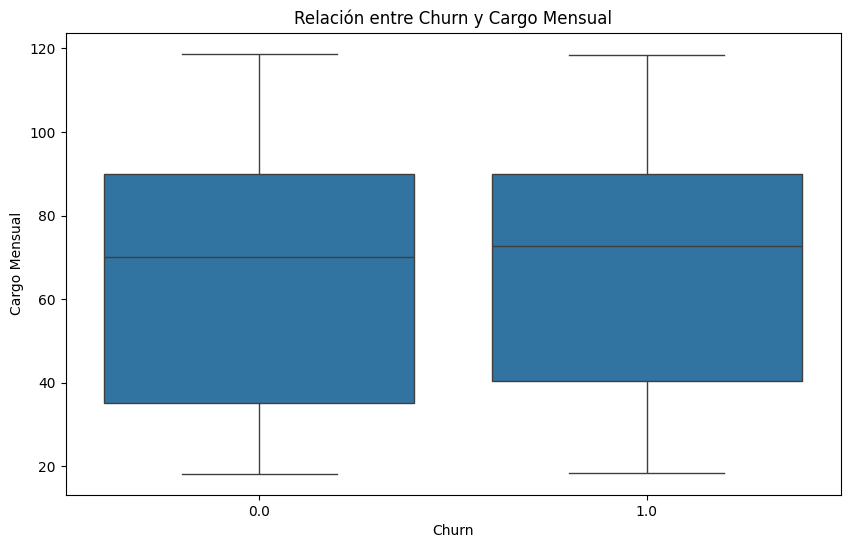

In [ ]:
#Investiga cómo variables específicas se relacionan con la cancelación

#1 Boxplot - Churn vs cargo mensual

plt.figure(figsize=(10, 6))
sns.boxplot(x='churn', y='remainder__cargo_mensual', data=datos_codificados)
plt.title('Relación entre Churn y Cargo Mensual')
plt.xlabel('Churn')
plt.ylabel('Cargo Mensual')
plt.show()

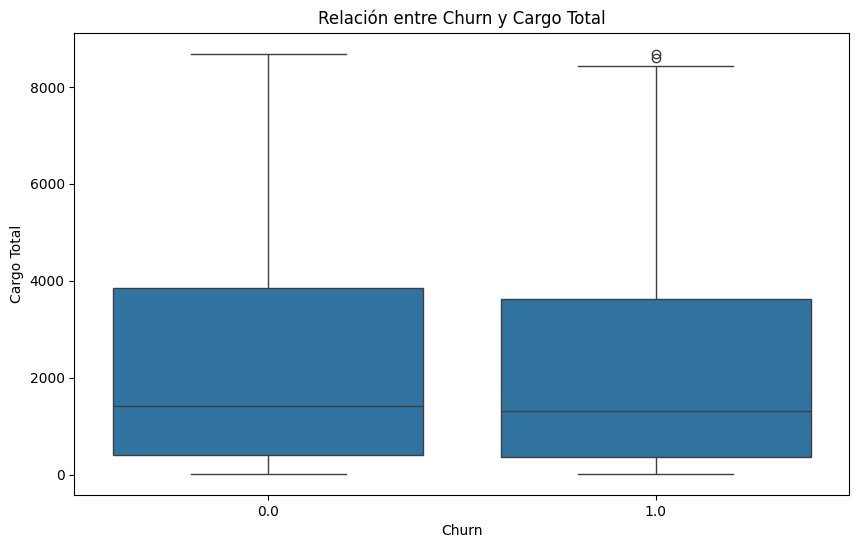

In [ ]:
#2 Boxplot - cargo_total vs churn
plt.figure(figsize=(10, 6))
sns.boxplot(x='churn', y='remainder__cargo_total', data=datos_codificados)
plt.title('Relación entre Churn y Cargo Total')
plt.xlabel('Churn')
plt.ylabel('Cargo Total')
plt.show()

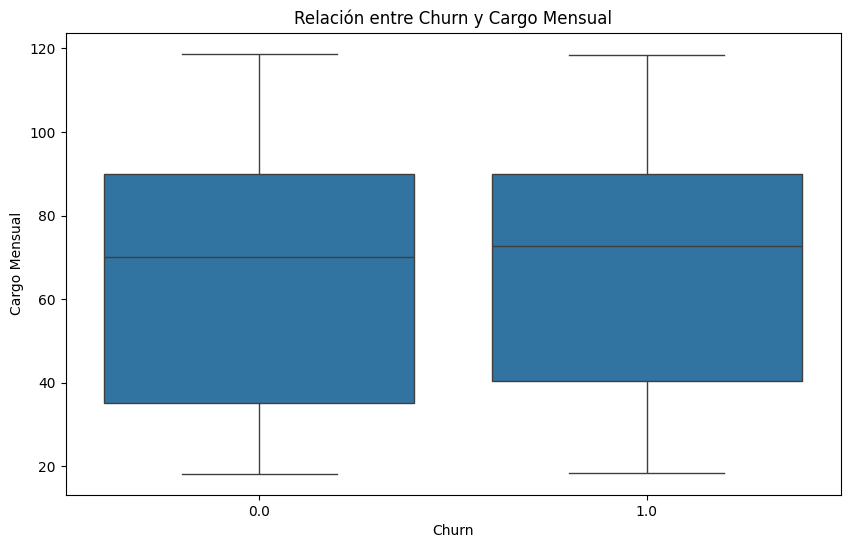

In [ ]:
#3 Boxplot - Churn vs cargo_mensual
plt.figure(figsize=(10, 6))
sns.boxplot(x='churn', y='remainder__cargo_mensual', data=datos_codificados)
plt.title('Relación entre Churn y Cargo Mensual')
plt.xlabel('Churn')
plt.ylabel('Cargo Mensual')
plt.show()

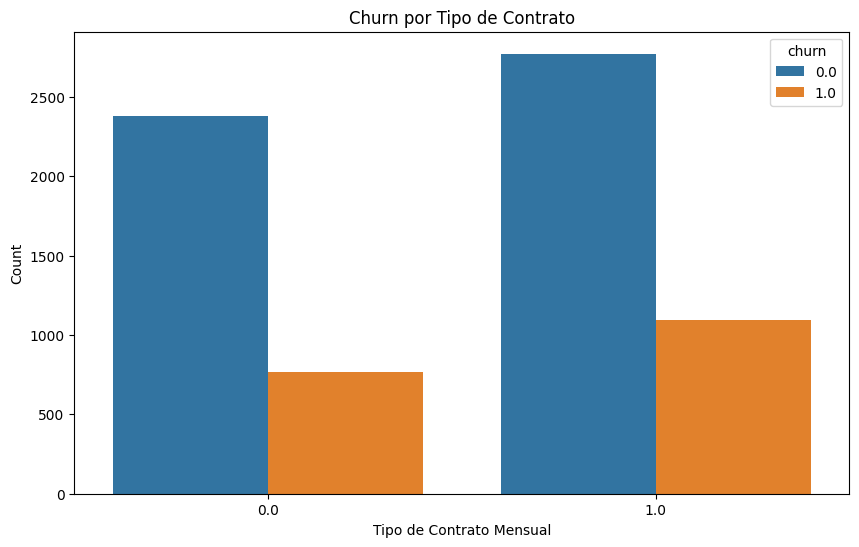

In [ ]:
#4 Countplot - Churn vs tipo_contrato
plt.figure(figsize=(10, 6))
sns.countplot(x='onehotencoder__tipo_contrato_Mensual', hue='churn', data=datos_codificados)
plt.title('Churn por Tipo de Contrato')
plt.xlabel('Tipo de Contrato Mensual')
plt.ylabel('Count')
plt.show()

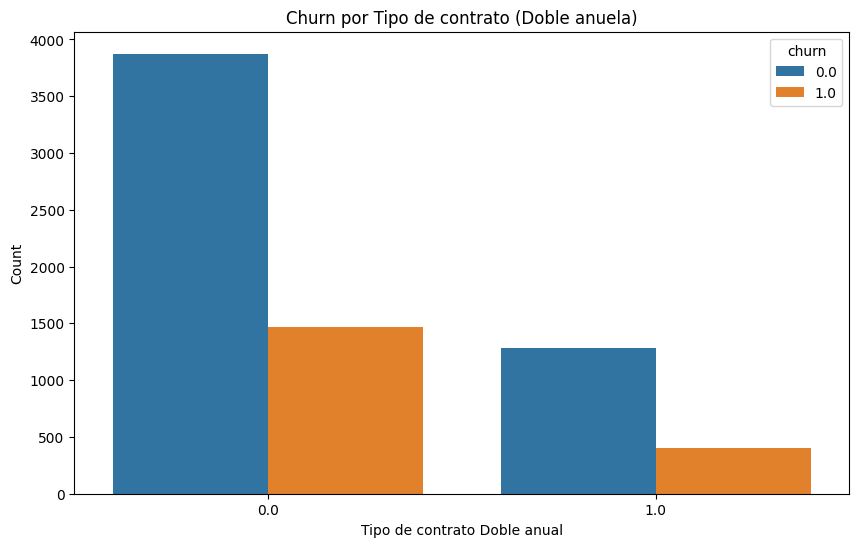

In [ ]:
# 5 Countplot - tipo_contrato_Doble_anual vs churn
plt.figure(figsize=(10, 6))
sns.countplot(x='onehotencoder__tipo_contrato_Doble Anual', hue='churn', data=datos_codificados)
plt.title('Churn por Tipo de contrato (Doble anuela)')
plt.xlabel('Tipo de contrato Doble anual')
plt.ylabel('Count')
plt.show()

In [ ]:
# Dividir los datos (70% entrenamiento, 30% prueba) con estratificación

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

In [ ]:
#Usar los datos balanceados usando SMOTE para dividir los datos
#en una proporción 7:3 (70% entrenamiento, 30% prueba) con estratificación

X_train_smote, X_test_smote, y_train_smote, y_test_smote = train_test_split(X_smote, y_smote, test_size=0.3, stratify=y_smote, random_state=42)

In [ ]:
#Estandarización de los datos
X_train_estandarizado = estandarizacion.fit_transform(X_train)
X_test_estandarizado = estandarizacion.transform(X_test)

X_train_estandarizado_smote = estandarizacion.fit_transform(X_train_smote)
X_test_estandarizado_smote = estandarizacion.transform(X_test_smote)

In [ ]:
#Creando el modelo Random Forest
from sklearn.ensemble import RandomForestClassifier

#Creando y entrenando el modelo
modelo_rf = RandomForestClassifier(random_state=42, max_depth=5)
modelo_rf.fit(X_train, y_train)

#Predicciones

y_predic_rf = modelo_rf.predict(X_test)

In [ ]:
#Creando el modelo Random Forest con SMOTE
from sklearn.ensemble import RandomForestClassifier

#Creando y entrenando el modelo
modelo_rf_estandarizado_smote = RandomForestClassifier(random_state=42, max_depth=5)
modelo_rf_estandarizado_smote.fit(X_train_estandarizado_smote, y_train_smote)

#Predicciones

y_predic_rf_smote = modelo_rf_estandarizado_smote.predict(X_test_estandarizado_smote)

In [ ]:
#Métricas: Matriz de Confusión, Accuracy(Exactitud), Recall, F1-Score, Precisión
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

print('Resultados Random Forest:')

print('Reporte de Clasificación:')
print(classification_report(y_test, y_predic_rf))

print('\nMatriz de Confusión:')
print(confusion_matrix(y_test, y_predic_rf))

print('\nExactitud del Modelo:')
print(accuracy_score(y_test, y_predic_rf))

print('\nPrecisión del Modelo:')
print(precision_score(y_test, y_predic_rf))

print('\nRecall del Modelo:')
print(recall_score(y_test, y_predic_rf))

print('\nF1-Score del Modelo:')
print(f1_score(y_test, y_predic_rf))

Resultados Random Forest:
Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.81      0.94      0.87      1549
           1       0.69      0.39      0.49       561

    accuracy                           0.79      2110
   macro avg       0.75      0.66      0.68      2110
weighted avg       0.78      0.79      0.77      2110


Matriz de Confusión:
[[1450   99]
 [ 345  216]]

Exactitud del Modelo:
0.7895734597156399

Precisión del Modelo:
0.6857142857142857

Recall del Modelo:
0.3850267379679144

F1-Score del Modelo:
0.4931506849315068


In [ ]:
#Métricas: Matriz de Confusión, Accuracy(Exactitud), Recall, F1-Score, Precisión
#con Datos Balanceados

print('Resultados Random Forest (Datos Balanceados):')

print('Reporte de Clasificación:')
print(classification_report(y_test_smote, y_predic_rf_smote))

print('\nMatriz de Confusión:')
print(confusion_matrix(y_test_smote, y_predic_rf_smote))

print('\nExactitud del Modelo:')
print(accuracy_score(y_test_smote, y_predic_rf_smote))

print('\nPrecisión del Modelo:')
print(precision_score(y_test_smote, y_predic_rf_smote))

print('\nRecall del Modelo:')
print(recall_score(y_test_smote, y_predic_rf_smote))

print('\nF1-Score del Modelo:')
print(f1_score(y_test_smote, y_predic_rf_smote))

Resultados Random Forest (Datos Balanceados):
Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.86      0.75      0.80      1549
           1       0.78      0.88      0.83      1549

    accuracy                           0.81      3098
   macro avg       0.82      0.81      0.81      3098
weighted avg       0.82      0.81      0.81      3098


Matriz de Confusión:
[[1158  391]
 [ 186 1363]]

Exactitud del Modelo:
0.8137508069722401

Precisión del Modelo:
0.7770809578107184

Recall del Modelo:
0.8799225306649451

F1-Score del Modelo:
0.8253103239479261


In [ ]:
#Creación y entrenamiento de modelo de Regresión Logística sin balanceo de los datos

from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

modelo_lr = LogisticRegression(random_state=42)
modelo_lr.fit(X_train_scaled, y_train)

y_predic_lr = modelo_lr.predict(X_test_scaled)

print('Resultados Regresión Logística:')

print('\nReporte de Clasificación:')
print(classification_report(y_test, y_predic_lr))

print('\nMatriz de Confusión:')
print(confusion_matrix(y_test, y_predic_lr))

print('\nExactitud del Modelo:')
print(accuracy_score(y_test, y_predic_lr))

print('\nPrecisión del Modelo:')
print(precision_score(y_test, y_predic_lr))

print('\nRecall del Modelo:')
print(recall_score(y_test, y_predic_lr))

print('\nF1-Score del Modelo:')
print(f1_score(y_test, y_predic_lr))

Resultados Regresión Logística:

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1549
           1       0.65      0.53      0.58       561

    accuracy                           0.80      2110
   macro avg       0.74      0.71      0.73      2110
weighted avg       0.79      0.80      0.79      2110


Matriz de Confusión:
[[1385  164]
 [ 262  299]]

Exactitud del Modelo:
0.7981042654028436

Precisión del Modelo:
0.6457883369330454

Recall del Modelo:
0.5329768270944741

F1-Score del Modelo:
0.583984375


In [ ]:
#Entrenamiento del modelo de Regresión Logística con datos balanceados

modelo_lr_smote = LogisticRegression(random_state=42)
modelo_lr_smote.fit(X_train_estandarizado_smote, y_train_smote)

y_predic_lr_smote = modelo_lr_smote.predict(X_test_estandarizado_smote)

print('Resultados Regresión Logística (Datos Balanceados):')

print('\nReporte de Clasificación:')
print(classification_report(y_test_smote, y_predic_lr_smote))

print('\nMatriz de Confusión:')
print(confusion_matrix(y_test_smote, y_predic_lr_smote))

print('\nExactitud del Modelo:')
print(accuracy_score(y_test_smote, y_predic_lr_smote))

print('\nPrecisión del Modelo:')
print(precision_score(y_test_smote, y_predic_lr_smote))

print('\nRecall del Modelo:')
print(recall_score(y_test_smote, y_predic_lr_smote))

print('\nF1-Score del Modelo:')
print(f1_score(y_test_smote, y_predic_lr_smote))

Resultados Regresión Logística (Datos Balanceados):

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.77      0.72      0.74      1549
           1       0.74      0.78      0.76      1549

    accuracy                           0.75      3098
   macro avg       0.75      0.75      0.75      3098
weighted avg       0.75      0.75      0.75      3098


Matriz de Confusión:
[[1113  436]
 [ 337 1212]]

Exactitud del Modelo:
0.750484183344093

Precisión del Modelo:
0.7354368932038835

Recall del Modelo:
0.7824402840542285

F1-Score del Modelo:
0.7582108226462309


In [ ]:
#Evaluamos la importancia y se muestra las features del modelo RandomForest

importances_modelo_rf = modelo_rf.feature_importances_

feature_importances_rf = pd.DataFrame({'Feature': X_df.columns, 'Importance': importances_modelo_rf})
feature_importances_rf = feature_importances_rf.sort_values(by='Importance', ascending=False)
feature_importances_rf

,Feature,Importance
16,onehotencoder__tipo_contrato_Mensual,0.229013
27,remainder__cargo_total,0.170030
1,onehotencoder__servicio_internet_Fibra Óptica,0.110931
15,onehotencoder__tipo_contrato_Doble Anual,0.103558
26,remainder__cargo_mensual,0.066651
9,onehotencoder__soporte_tecnico_1,0.039180
3,onehotencoder__seguridad_en_linea_1,0.038043
6,onehotencoder__respaldo_en_linea_No internet s...,0.029435
2,onehotencoder__servicio_internet_No,0.025912
12,onehotencoder__tv_streaming_No internet service,0.021797


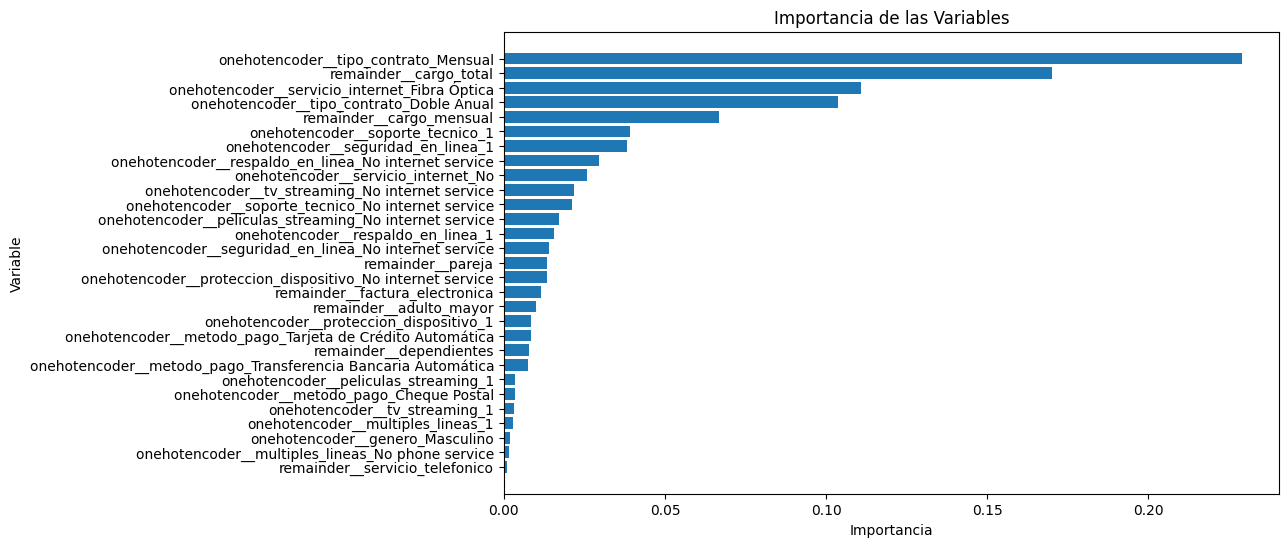

In [ ]:
#Graficando los resultados
plt.figure(figsize=(10, 6))
plt.barh(feature_importances_rf['Feature'], feature_importances_rf['Importance'])
plt.gca().invert_yaxis()
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.title('Importancia de las Variables')
plt.show()

In [ ]:
#Evaluamos la importancia y se muestra las features del modelo RandomForest Balanceado

importances_modelo_rf_smote = modelo_rf_estandarizado_smote.feature_importances_

feature_importances_rf_smote = pd.DataFrame({'Feature': X_df.columns, 'Importance': importances_modelo_rf_smote})
feature_importances_rf_smote = feature_importances_rf_smote.sort_values(by='Importance', ascending=False)
feature_importances_rf_smote

,Feature,Importance
16,onehotencoder__tipo_contrato_Mensual,0.248272
15,onehotencoder__tipo_contrato_Doble Anual,0.106042
9,onehotencoder__soporte_tecnico_1,0.085475
1,onehotencoder__servicio_internet_Fibra Óptica,0.076997
23,remainder__pareja,0.057541
3,onehotencoder__seguridad_en_linea_1,0.057253
25,remainder__factura_electronica,0.054988
27,remainder__cargo_total,0.052672
24,remainder__dependientes,0.030512
2,onehotencoder__servicio_internet_No,0.025395


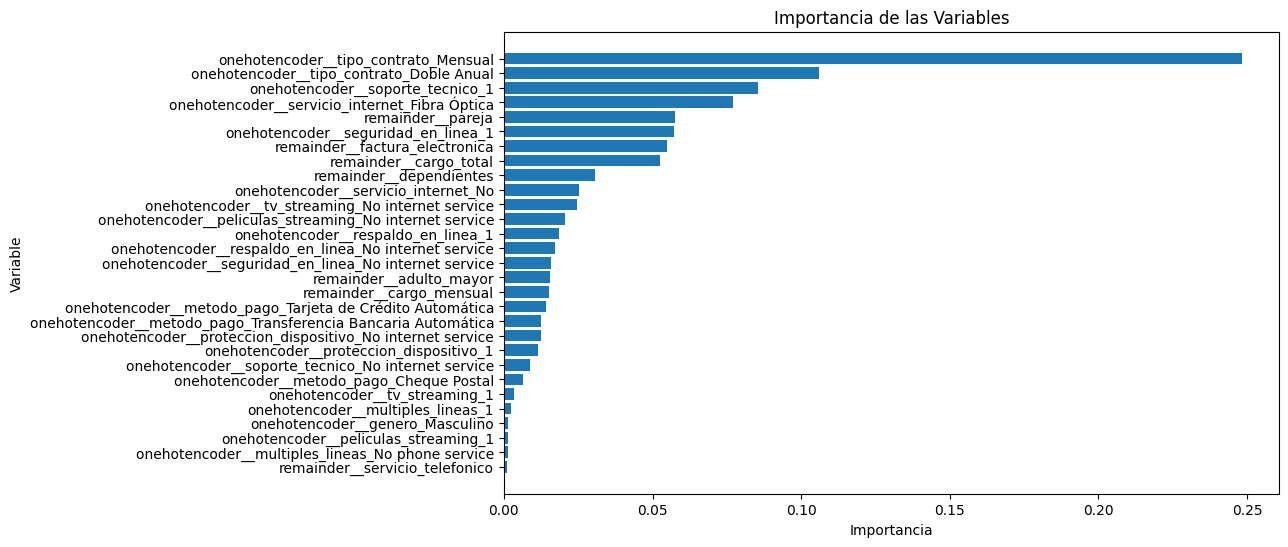

In [ ]:
#Graficando los resultados
plt.figure(figsize=(10, 6))
plt.barh(feature_importances_rf_smote['Feature'], feature_importances_rf_smote['Importance'])
plt.gca().invert_yaxis()
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.title('Importancia de las Variables')
plt.show()

In [ ]:
#Evaluamos la importancia y se muestra las features del modelo Regresion Logistica

importances_modelo_lg = np.abs(modelo_lr.coef_[0])

feature_importances_lg = pd.DataFrame({'Feature': X_df.columns, 'Importance': importances_modelo_lg})
feature_importances_lg = feature_importances_lg.sort_values(by='Importance', ascending=False)
feature_importances_lg

,Feature,Importance
27,remainder__cargo_total,0.664157
1,onehotencoder__servicio_internet_Fibra Óptica,0.646637
16,onehotencoder__tipo_contrato_Mensual,0.437230
26,remainder__cargo_mensual,0.324309
15,onehotencoder__tipo_contrato_Doble Anual,0.298757
11,onehotencoder__tv_streaming_1,0.231812
18,onehotencoder__metodo_pago_Tarjeta de Crédito ...,0.216965
19,onehotencoder__metodo_pago_Transferencia Banca...,0.186085
13,onehotencoder__peliculas_streaming_1,0.184301
25,remainder__factura_electronica,0.173042


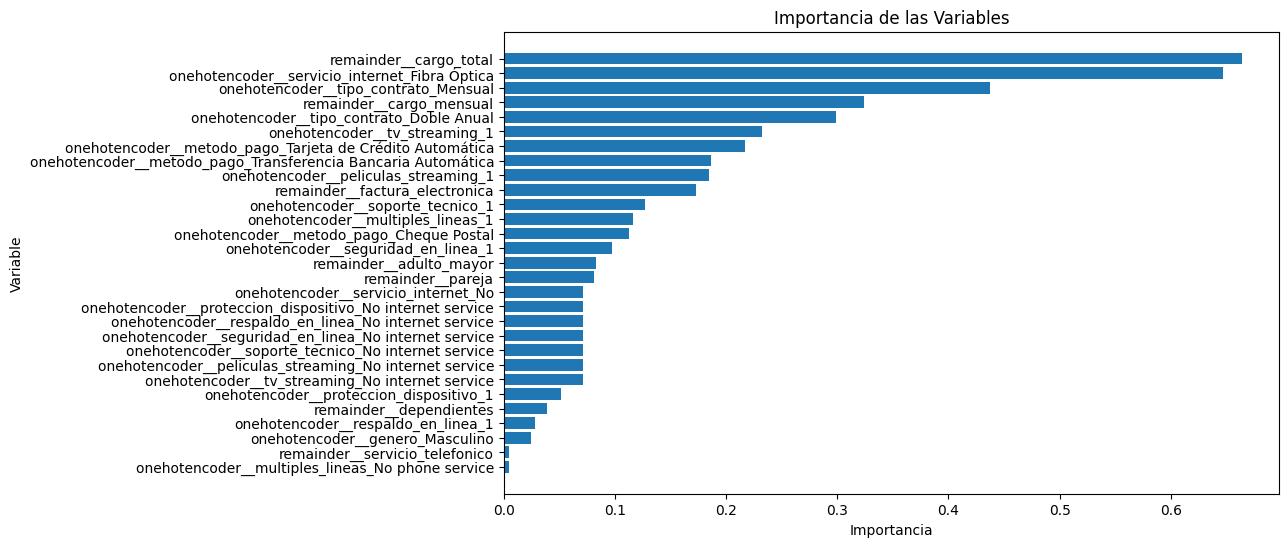

In [ ]:
#Graficando los resultados
plt.figure(figsize=(10, 6))
plt.barh(feature_importances_lg['Feature'], feature_importances_lg['Importance'])
plt.gca().invert_yaxis()
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.title('Importancia de las Variables')
plt.show()

In [ ]:
#Evaluamos la importancia y se muestra las features del modelo Regresion Logistica Balanceado

importances_modelo_lg_smote = np.abs(modelo_lr_smote.coef_[0])

feature_importances_lg_smote = pd.DataFrame({'Feature': X_df.columns, 'Importance': importances_modelo_lg_smote})
feature_importances_lg_smote = feature_importances_lg_smote.sort_values(by='Importance', ascending=False)
feature_importances_lg_smote

,Feature,Importance
27,remainder__cargo_total,0.527725
16,onehotencoder__tipo_contrato_Mensual,0.474924
1,onehotencoder__servicio_internet_Fibra Óptica,0.409486
15,onehotencoder__tipo_contrato_Doble Anual,0.308219
18,onehotencoder__metodo_pago_Tarjeta de Crédito ...,0.221627
19,onehotencoder__metodo_pago_Transferencia Banca...,0.208318
26,remainder__cargo_mensual,0.190143
3,onehotencoder__seguridad_en_linea_1,0.165839
9,onehotencoder__soporte_tecnico_1,0.164440
25,remainder__factura_electronica,0.154661


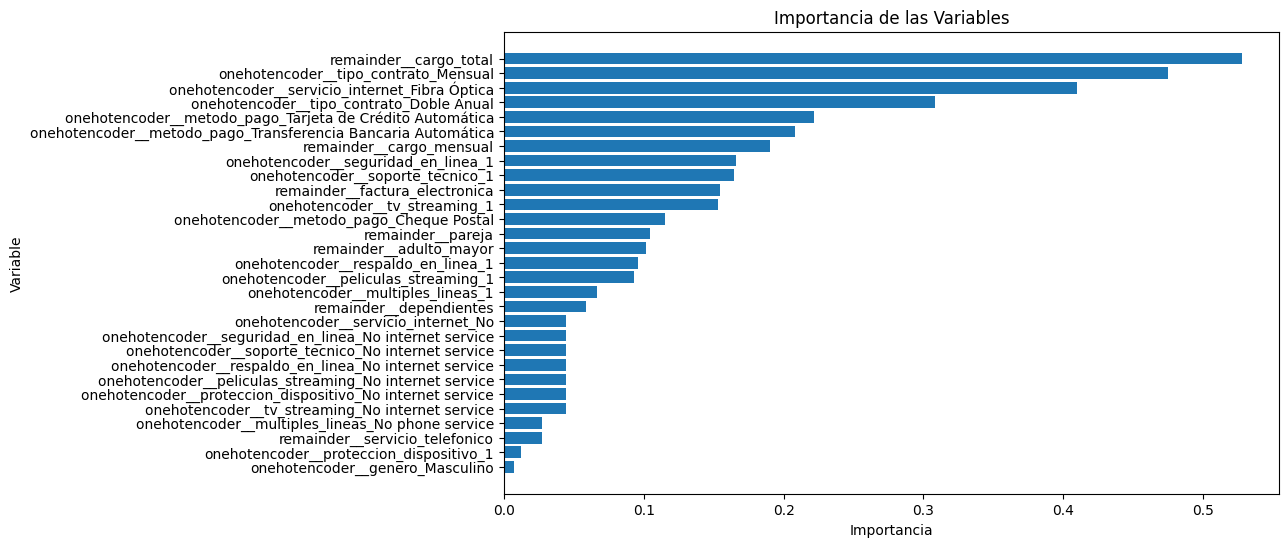

In [ ]:
#Graficando los resultados
plt.figure(figsize=(10, 6))
plt.barh(feature_importances_lg_smote['Feature'], feature_importances_lg_smote['Importance'])
plt.gca().invert_yaxis()
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.title('Importancia de las Variables')
plt.show()

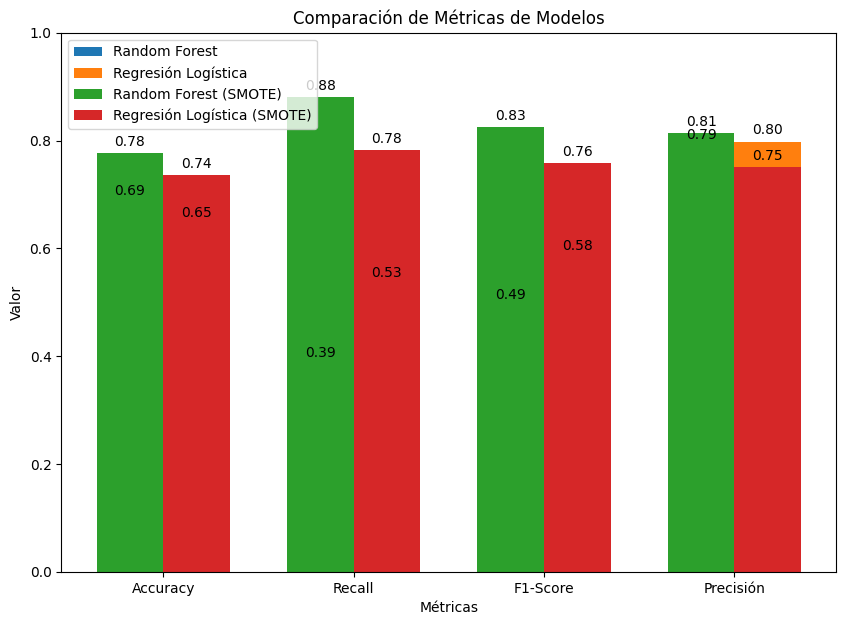

In [ ]:
#Otras métricas

metricas = ['Accuracy', 'Recall', 'F1-Score', 'Precisión']
metricas_rf = [
    precision_score(y_test, y_predic_rf),
    recall_score(y_test, y_predic_rf),
    f1_score(y_test, y_predic_rf),
    accuracy_score(y_test, y_predic_rf)
]

metricas_rf_smote = [
    precision_score(y_test_smote, y_predic_rf_smote),
    recall_score(y_test_smote, y_predic_rf_smote),
    f1_score(y_test_smote, y_predic_rf_smote),
    accuracy_score(y_test_smote, y_predic_rf_smote)
]

metricas_lr = [
    precision_score(y_test, y_predic_lr),
    recall_score(y_test, y_predic_lr),
    f1_score(y_test, y_predic_lr),
    accuracy_score(y_test, y_predic_lr)
]

metricas_lr_smote = [
    precision_score(y_test_smote, y_predic_lr_smote),
    recall_score(y_test_smote, y_predic_lr_smote),
    f1_score(y_test_smote, y_predic_lr_smote),
    accuracy_score(y_test_smote, y_predic_lr_smote)
]

x = np.arange(len(metricas))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 7))
rects_rf = ax.bar(x - width/2, metricas_rf, width, label='Random Forest')
rects_lr = ax.bar(x + width/2, metricas_lr, width, label='Regresión Logística')
rects_rf_smote = ax.bar(x - width/2, metricas_rf_smote, width, label='Random Forest (SMOTE)')
rects_lr_smote = ax.bar(x + width/2, metricas_lr_smote, width, label='Regresión Logística (SMOTE)')

ax.set_xlabel('Métricas')
ax.set_ylabel('Valor')
ax.set_title('Comparación de Métricas de Modelos')
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.legend()

#Mostrar los valores en cada barra
for rects in [rects_rf, rects_lr, rects_rf_smote, rects_lr_smote]:
    for rect in rects:
      height = rect.get_height()
      ax.annotate(f'{height:.2f}',
                  xy=(rect.get_x() + rect.get_width() / 2, height),
                  xytext=(0, 3),  # Desplazamiento vertical
                  textcoords="offset points",
                  ha='center', va='bottom')

plt.ylim(0, 1)  # Escala de 0 a 1
plt.show()

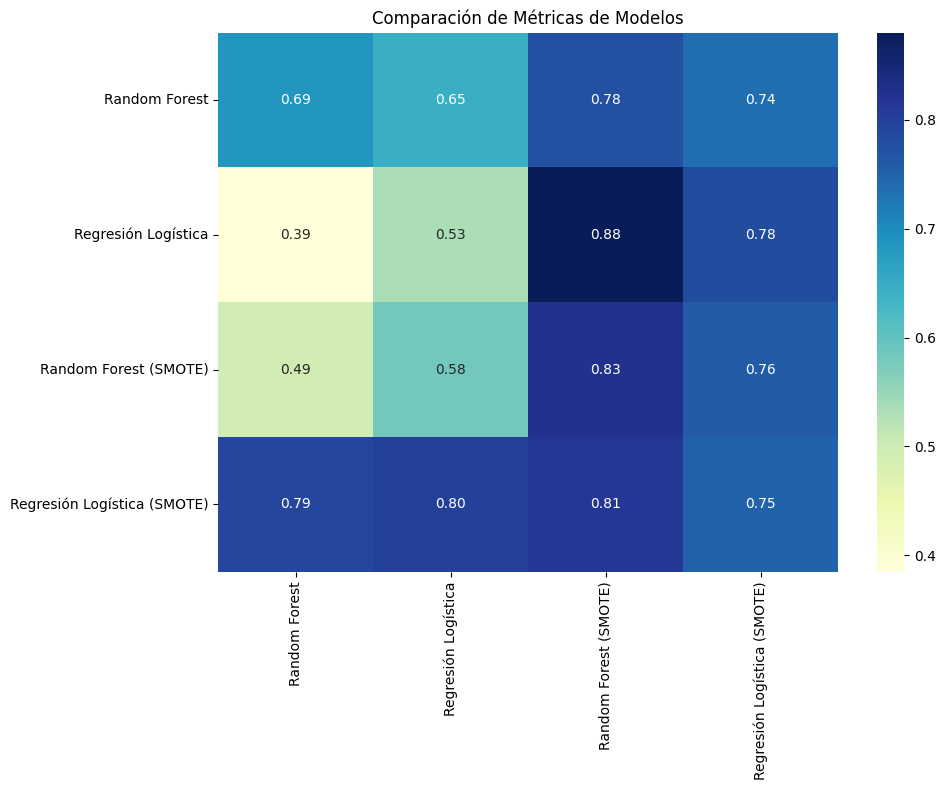

In [ ]:
#HeadMap comparativo

data_modelos = {
    'Random Forest': metricas_rf,
    'Regresión Logística': metricas_lr,
    'Random Forest (SMOTE)': metricas_rf_smote,
    'Regresión Logística (SMOTE)': metricas_lr_smote
    }
nombres_modelos = ['Random Forest', 'Regresión Logística', 'Random Forest (SMOTE)', 'Regresión Logística (SMOTE)']

df_metricas = pd.DataFrame(data_modelos, index=nombres_modelos)

plt.figure(figsize=(10, 7))
sns.heatmap(df_metricas, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Comparación de Métricas de Modelos')
plt.show()

In [ ]:
#Random Forest: Utiliza la importancia de las variables proporcionada por el modelo.

#Obtener importancias

importancias_rf = modelo_rf.feature_importances_
features = X_df.columns

#Crearondo un DataFrame con resultados

importancias_rf = pd.DataFrame({'Variable': features, 'Importancia': importancias_rf})
importancias_rf = importancias_rf.sort_values(by='Importancia', ascending=False)

#Mostrando las 10 más importantes
print(importancias_rf.head(10))

                                             Variable  Importancia
16               onehotencoder__tipo_contrato_Mensual     0.229013
27                             remainder__cargo_total     0.170030
1       onehotencoder__servicio_internet_Fibra Óptica     0.110931
15           onehotencoder__tipo_contrato_Doble Anual     0.103558
26                           remainder__cargo_mensual     0.066651
9                    onehotencoder__soporte_tecnico_1     0.039180
3                 onehotencoder__seguridad_en_linea_1     0.038043
6   onehotencoder__respaldo_en_linea_No internet s...     0.029435
2                 onehotencoder__servicio_internet_No     0.025912
12    onehotencoder__tv_streaming_No internet service     0.021797


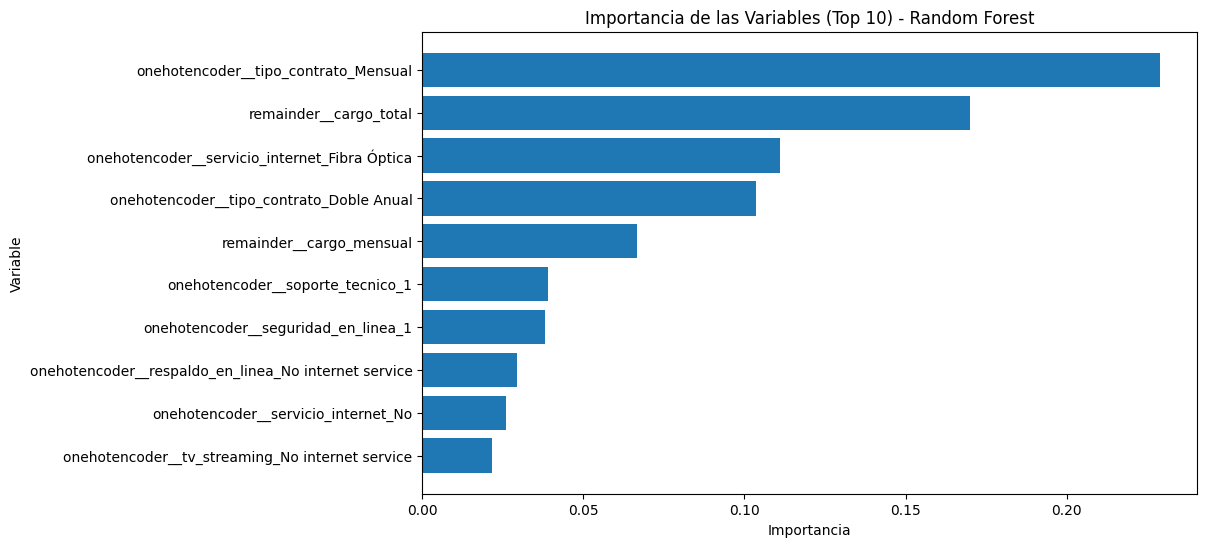

In [ ]:
#Graficando importancia

plt.figure(figsize=(10, 6))
plt.barh(importancias_rf['Variable'][:10], importancias_rf['Importancia'][:10])
plt.gca().invert_yaxis()
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.title('Importancia de las Variables (Top 10) - Random Forest')
plt.show()

In [ ]:
#Importancia de Random Forest (SMOTE)

#Obteniendo importancia
importancias_rf_smote = modelo_rf_estandarizado_smote.feature_importances_
features_smote = X_df.columns

#Creadno el DataFrame correpondiente

importancias_rf_smote = pd.DataFrame({'Variable': features_smote, 'Importancia': importancias_rf_smote})
importancias_rf_smote = importancias_rf_smote.sort_values(by='Importancia', ascending=False)

#Imprimiendo 10 mejores

print(importancias_rf_smote.head(10))

                                         Variable  Importancia
16           onehotencoder__tipo_contrato_Mensual     0.248272
15       onehotencoder__tipo_contrato_Doble Anual     0.106042
9                onehotencoder__soporte_tecnico_1     0.085475
1   onehotencoder__servicio_internet_Fibra Óptica     0.076997
23                              remainder__pareja     0.057541
3             onehotencoder__seguridad_en_linea_1     0.057253
25                 remainder__factura_electronica     0.054988
27                         remainder__cargo_total     0.052672
24                        remainder__dependientes     0.030512
2             onehotencoder__servicio_internet_No     0.025395


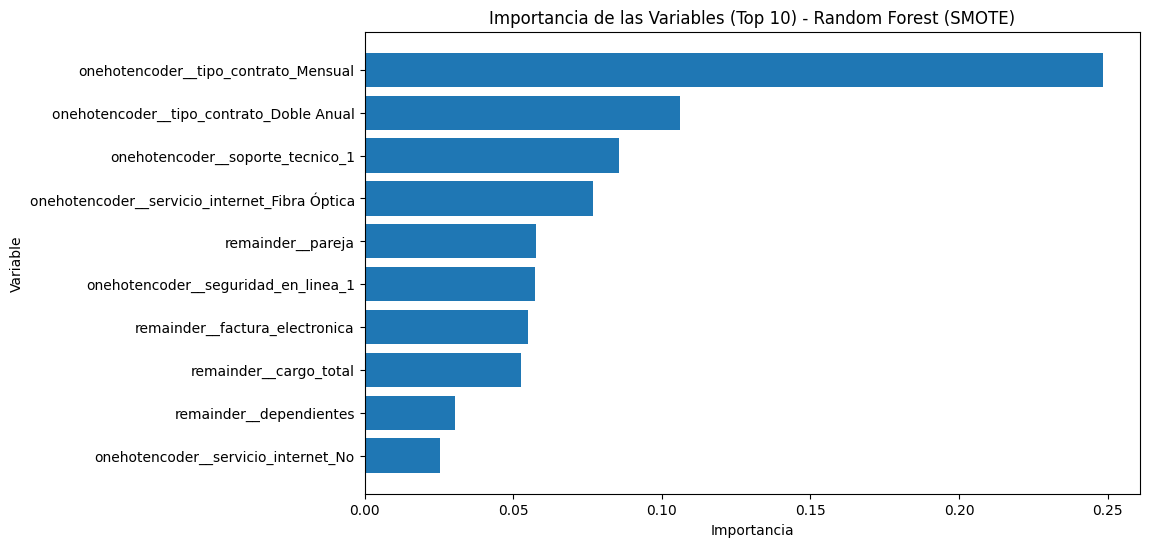

In [ ]:
#Graficando importancia

plt.figure(figsize=(10, 6))
plt.barh(importancias_rf_smote['Variable'][:10], importancias_rf_smote['Importancia'][:10])
plt.gca().invert_yaxis()
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.title('Importancia de las Variables (Top 10) - Random Forest (SMOTE)')
plt.show()

In [ ]:
#Regresión Logística: Investiga los coeficientes de las variables,
#que muestran su contribución a la predicción de cancelación.

#Obteniendo los coficientes

coeficientes_lr = modelo_lr.coef_[0]
features_lr = X_df.columns

#Creando el DataFrame

df_coeficientes_lr = pd.DataFrame({'Variable': features_lr, 'Coeficiente': coeficientes_lr, 'Importancia_Absoluta': np.abs(coeficientes_lr)})
df_coeficientes_lr = df_coeficientes_lr.sort_values(by='Importancia_Absoluta', ascending=False)

#Mostrando los 10 coeficientes más importantes

print(df_coeficientes_lr.head(10))

                                             Variable  Coeficiente  \
27                             remainder__cargo_total    -0.664157   
1       onehotencoder__servicio_internet_Fibra Óptica     0.646637   
16               onehotencoder__tipo_contrato_Mensual     0.437230   
26                           remainder__cargo_mensual    -0.324309   
15           onehotencoder__tipo_contrato_Doble Anual    -0.298757   
11                      onehotencoder__tv_streaming_1     0.231812   
18  onehotencoder__metodo_pago_Tarjeta de Crédito ...    -0.216965   
19  onehotencoder__metodo_pago_Transferencia Banca...    -0.186085   
13               onehotencoder__peliculas_streaming_1     0.184301   
25                     remainder__factura_electronica     0.173042   

    Importancia_Absoluta  
27              0.664157  
1               0.646637  
16              0.437230  
26              0.324309  
15              0.298757  
11              0.231812  
18              0.216965  
19           

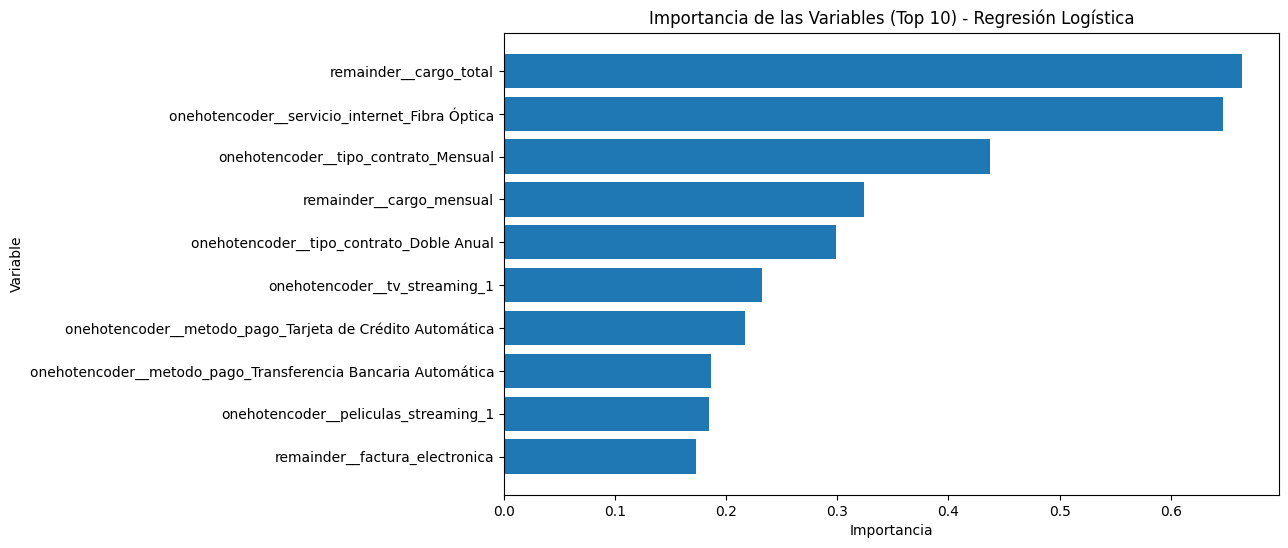

In [ ]:
#Gráficando la importancia

plt.figure(figsize=(10, 6))
plt.barh(df_coeficientes_lr['Variable'][:10], df_coeficientes_lr['Importancia_Absoluta'][:10])
plt.gca().invert_yaxis()
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.title('Importancia de las Variables (Top 10) - Regresión Logística')
plt.show()

In [ ]:
#Regresión Logística - SMOTE

#Obteniendo los coficientes

coeficientes_lr_smote = modelo_lr_smote.coef_[0]
features_lr_smote = X_df.columns

#Creando el DataFrame

df_coeficientes_lr_smote = pd.DataFrame({'Variable': features_lr_smote, 'Coeficiente': coeficientes_lr_smote, 'Importancia_Absoluta': np.abs(coeficientes_lr_smote)})
df_coeficientes_lr_smote = df_coeficientes_lr.sort_values(by='Importancia_Absoluta', ascending=False)

#Mostrando los 10 coeficientes más importantes

print(df_coeficientes_lr.head(10))

                                             Variable  Coeficiente  \
27                             remainder__cargo_total    -0.664157   
1       onehotencoder__servicio_internet_Fibra Óptica     0.646637   
16               onehotencoder__tipo_contrato_Mensual     0.437230   
26                           remainder__cargo_mensual    -0.324309   
15           onehotencoder__tipo_contrato_Doble Anual    -0.298757   
11                      onehotencoder__tv_streaming_1     0.231812   
18  onehotencoder__metodo_pago_Tarjeta de Crédito ...    -0.216965   
19  onehotencoder__metodo_pago_Transferencia Banca...    -0.186085   
13               onehotencoder__peliculas_streaming_1     0.184301   
25                     remainder__factura_electronica     0.173042   

    Importancia_Absoluta  
27              0.664157  
1               0.646637  
16              0.437230  
26              0.324309  
15              0.298757  
11              0.231812  
18              0.216965  
19           

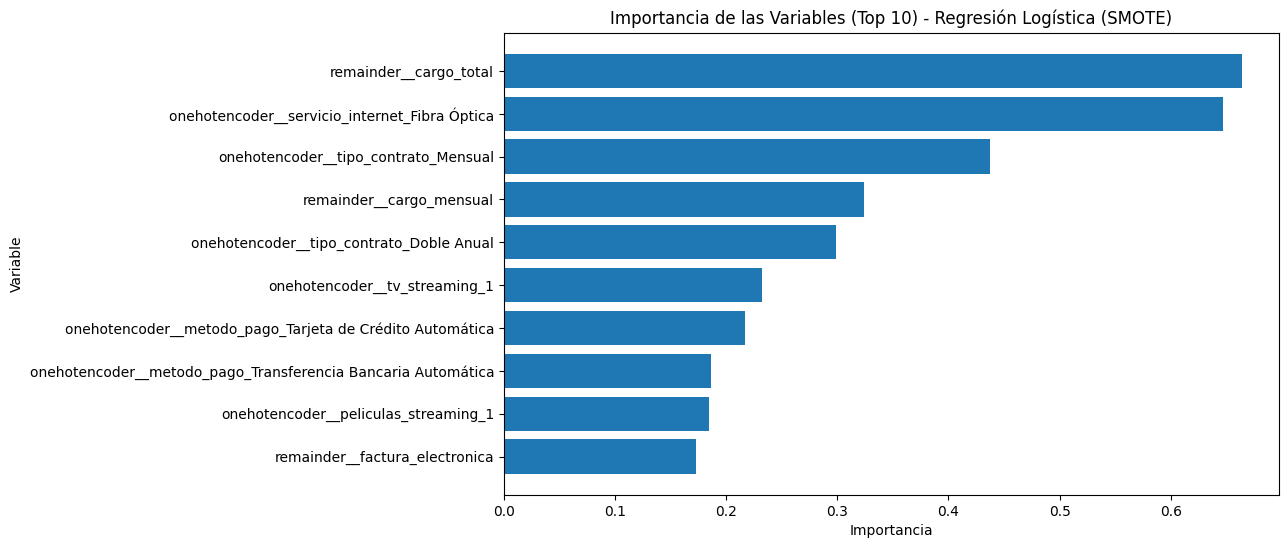

In [ ]:
#Gráficando la importancia

plt.figure(figsize=(10, 6))
plt.barh(df_coeficientes_lr_smote['Variable'][:10], df_coeficientes_lr_smote['Importancia_Absoluta'][:10])
plt.gca().invert_yaxis()
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.title('Importancia de las Variables (Top 10) - Regresión Logística (SMOTE)')
plt.show()

Conclusiones del proyecto

Para finalizar este proyecto, se presentan una serie de conclusiones basadas en los resultados obtenidos a partir de los modelos desarrollados. Para ello, se analizan tres aspectos clave que permiten comprender con mayor claridad los factores que tienen mayor impacto en la cancelación de clientes.

1. Selección de los mejores modelos

Durante el desarrollo del proyecto se evaluaron dos modelos de machine learning: Random Forest y Regresión Logística. Ambos fueron entrenados y evaluados utilizando dos escenarios distintos: con datos originales (desbalanceados) y con datos balanceados mediante oversampling con SMOTE.

Al utilizar las mismas métricas de evaluación para todos los casos, es posible comparar su desempeño y extraer las siguientes conclusiones.

1.1 Random Forest

Sin balanceo: presenta un accuracy alto (0.79), pero un recall bajo para la clase positiva (0.38), lo que indica que el modelo detecta pocos casos de churn.

Con balanceo (SMOTE): el accuracy disminuye a 0.69, pero el recall aumenta considerablemente a 0.57 y el F1-score mejora a 0.65.

Elección: Random Forest con datos balanceados.
Esto se debe a que el objetivo principal es identificar clientes que cancelan el servicio, por lo que métricas como recall y F1-score resultan más relevantes que el accuracy.

1.2 Regresión Logística

Sin balanceo: accuracy de 0.71, con recall muy alto (0.82) para la clase positiva, pero precisión baja (0.47).

Con balanceo (SMOTE): accuracy de 0.75, recall de 0.78 y precisión más equilibrada (0.73).

Elección: Regresión Logística con datos balanceados, ya que logra un mejor equilibrio entre recall y precisión, manteniendo un buen rendimiento general.

2. Análisis de los principales factores que influyen en la cancelación

Una vez identificados los modelos con mejor desempeño (ambos utilizando datos balanceados), se analizan las variables más influyentes en cada modelo para interpretar qué factores están asociados a la cancelación de clientes.

2.1 Random Forest – Variables más relevantes

Las cinco variables con mayor importancia en el modelo son:

Tipo de contrato: Mensual (0.248)
Los clientes con contratos mensuales presentan mayor probabilidad de cancelar el servicio.

Tipo de contrato: Doble anual (0.106)
Está asociado a una menor probabilidad de churn.

Soporte técnico activo (0.085)
Reduce la probabilidad de cancelación.

Servicio de Internet: Fibra óptica (0.077)
Se encuentra más asociado a cancelaciones que otras tecnologías.

Pareja (0.057)
Los clientes que viven en pareja tienden a cancelar menos.

Interpretación:
Los contratos de corto plazo y el servicio de fibra óptica aparecen como factores de mayor riesgo de cancelación, mientras que servicios adicionales como soporte técnico y contratos de mayor duración contribuyen a la retención de clientes.

2.2 Regresión Logística – Variables más relevantes

Las cinco variables más influyentes en este modelo son:

Servicio de Internet: Fibra óptica (+0.887)
Incrementa la probabilidad de churn.

Tipo de contrato: Mensual (+0.737)
Asociado a una mayor probabilidad de cancelación.

Tipo de contrato: Doble anual (−0.686)
Reduce significativamente la probabilidad de churn.

Método de pago: Tarjeta de crédito (−0.586)
Asociado a menor riesgo de cancelación.

Método de pago: Transferencia bancaria (−0.502)
También reduce el riesgo de churn.

Interpretación:
Los resultados coinciden con los obtenidos en Random Forest: los contratos mensuales y el servicio de fibra óptica aparecen como señales de riesgo, mientras que métodos de pago más estables se asocian a clientes con mayor permanencia.

3. Comparación entre modelos y conclusiones finales

A partir de la selección de modelos y del análisis de variables relevantes, es posible identificar varias coincidencias entre ambos enfoques.

Coincidencias principales

Ambos modelos identifican que los contratos mensuales y el servicio de fibra óptica son los principales factores de riesgo de cancelación.

Las variables relacionadas con servicios adicionales (como soporte técnico o seguridad en línea) contribuyen a la retención de clientes.

Los métodos de pago automáticos, como tarjeta de crédito o transferencia bancaria, se asocian con menor churn, posiblemente debido a la automatización de los pagos.

Diferencias entre los modelos

Random Forest identifica una mayor cantidad de factores secundarios (pareja, factura electrónica, dependientes).

Regresión Logística resulta más interpretable, ya que permite comprender fácilmente la dirección del efecto de cada variable (coeficientes positivos aumentan el riesgo, negativos lo reducen).

Comparación de métricas

Random Forest con SMOTE:
Mejora el F1-score (0.65) respecto al modelo sin balanceo, aunque presenta menor precisión que la Regresión Logística.

Regresión Logística con SMOTE:
Presenta el mejor equilibrio general, con accuracy de 0.75, recall de 0.78 y precisión de 0.73.

Conclusiones generales

A partir del análisis de los modelos y sus métricas, se pueden establecer las siguientes conclusiones:

Para predicción de churn con mayor capacidad explicativa, el modelo más adecuado es la Regresión Logística Balanceada.

Para identificar múltiples variables influyentes y maximizar la detección de casos de churn, el modelo más apropiado es Random Forest Balanceado.

Recomendaciones para la empresa Telecom X

En función de los resultados obtenidos, se sugieren las siguientes acciones estratégicas para reducir la cancelación de clientes:

Incentivar contratos de mayor duración, ofreciendo beneficios o descuentos frente a los contratos mensuales.

Mejorar la experiencia del servicio de fibra óptica, analizando posibles problemas de calidad o soporte.

Promover métodos de pago automáticos, como tarjeta de crédito o transferencia bancaria.

Ofrecer servicios adicionales de valor, como soporte técnico o seguridad en línea, que contribuyan a aumentar la fidelización de los clientes.

Si quieres, también puedo dejarte una versión todavía más “académica” (nivel informe de ciencia de datos o trabajo final) o una versión más corta y potente para GitHub/portafolio, que suele quedar mucho mejor para proyectos de análisis de datos.